# LightGuard — Live Demo

**Offline explainable malware detection for home Windows users.**

Run top-to-bottom. Everything executes locally — no internet required after setup.

| | |
|---|---|
| **RQ1** | Can a local, offline model detect PE malware with AUC > 0.95 on held-out data? |
| **RQ2** | Can the model explain *why* in plain English — without a cloud lookup? |

---

In [1]:
# ── environment setup ─────────────────────────────────────────────────────────
import sys, warnings
from pathlib import Path

REPO = Path(".").resolve().parent   # notebooks/ → repo root
sys.path.insert(0, str(REPO / "src"))
warnings.filterwarnings("ignore")

import json
import numpy as np
import yaml
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

cfg = yaml.safe_load((REPO / "config.yaml").read_text())
RNG = np.random.default_rng(cfg["random_seed"])

# ── paths ─────────────────────────────────────────────────────────────────────
MODEL_PATH   = REPO / "models" / "lightguard_lgbm.txt"
METRICS_PATH = REPO / "reports" / "metrics.json"
BENIGN_EXE   = REPO / "data" / "sample" / "benign.exe"
SAMPLE_DIR   = REPO / "data" / "sample"

# prefer holdout slice exported by Colab; fall back to committed sample
_x_name = "test_holdout_X.npy" if (SAMPLE_DIR / "test_holdout_X.npy").exists() else "X_test.npy"
_y_name = "test_holdout_y.npy" if (SAMPLE_DIR / "test_holdout_y.npy").exists() else "y_test.npy"

X_demo = np.load(SAMPLE_DIR / _x_name)
y_demo = np.load(SAMPLE_DIR / _y_name)

print(f"Using  {_x_name}  ({len(X_demo)} rows, "
      f"{int((y_demo==0).sum())} benign / {int((y_demo==1).sum())} malicious)")
print(f"Model: {MODEL_PATH}  (exists={MODEL_PATH.exists()})")

Using  X_test.npy  (200 rows, 100 benign / 100 malicious)
Model: /Users/sanskritikhanal/Desktop/LightGuard/models/lightguard_lgbm.txt  (exists=True)


---
## 1 — Model performance (RQ1)

Metrics were computed on:
- **Test set** — 240 000 samples from EMBER2024 weeks 53-64 (never seen during training)
- **Challenge set** — 6 315 evasive malware + benign controls (adversarial)

Baselines: Logistic Regression and Random Forest trained on a 100 k subsample.

In [2]:
metrics = json.loads(METRICS_PATH.read_text())

# ── comparison table ──────────────────────────────────────────────────────────
rows = []
labels = {"lightguard_lgbm": "LightGuard (LightGBM)",
          "baseline_rf": "Baseline — Random Forest",
          "baseline_lr": "Baseline — Logistic Reg."}

for key, name in labels.items():
    t = metrics[key]["test"]
    c = metrics[key]["challenge"]
    rows.append({
        "Model":          name,
        "Test AUC":       f"{t['roc_auc']:.4f}",
        "Test F1":        f"{t['f1']:.4f}",
        "Challenge AUC":  f"{c['roc_auc']:.4f}",
        "Challenge F1":   f"{c['f1']:.4f}",
    })

df = pd.DataFrame(rows).set_index("Model")
print("\n── AUC / F1 comparison ──────────────────────────────────────────────")
display(df.style.set_caption("All metrics at threshold = 0.80"))


── AUC / F1 comparison ──────────────────────────────────────────────


,Test AUC,Test F1,Challenge AUC,Challenge F1
Model,,,,
LightGuard (LightGBM),0.9958,0.9615,0.9482,0.4843
Baseline — Random Forest,0.9899,0.8661,0.9188,0.3902
Baseline — Logistic Reg.,0.9271,0.6993,0.7137,0.1157


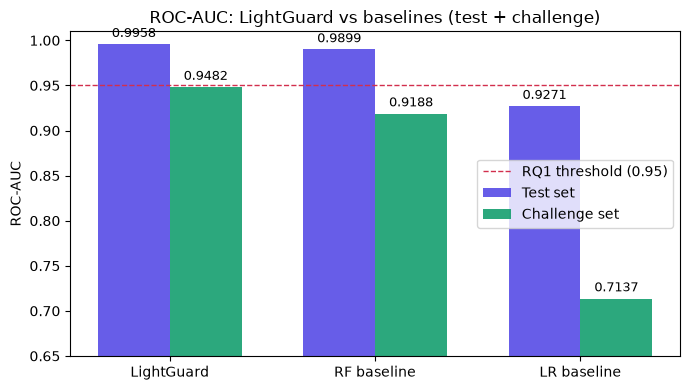


RQ1 answer: LightGuard test AUC = 0.9958  (target ≥ 0.95 ✓)
          challenge AUC = 0.9482  (evasive malware — harder by design)


In [3]:
# ── bar chart: AUC on test vs challenge ───────────────────────────────────────
model_names   = ["LightGuard", "RF baseline", "LR baseline"]
model_keys    = ["lightguard_lgbm", "baseline_rf", "baseline_lr"]
test_aucs      = [metrics[k]["test"]["roc_auc"]      for k in model_keys]
challenge_aucs = [metrics[k]["challenge"]["roc_auc"] for k in model_keys]

x   = np.arange(len(model_names))
w   = 0.35
fig, ax = plt.subplots(figsize=(7, 4))

bars1 = ax.bar(x - w/2, test_aucs,      w, label="Test set",      color="#5246E5", alpha=0.88)
bars2 = ax.bar(x + w/2, challenge_aucs, w, label="Challenge set", color="#0E9C6B", alpha=0.88)

ax.bar_label(bars1, fmt="%.4f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.4f", padding=3, fontsize=9)

ax.axhline(0.95, color="#D22F4D", linestyle="--", linewidth=1, label="RQ1 threshold (0.95)")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.65, 1.01)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))
ax.set_title("ROC-AUC: LightGuard vs baselines (test + challenge)")
ax.legend()
fig.tight_layout()
plt.show()

lg_test = metrics["lightguard_lgbm"]["test"]["roc_auc"]
lg_chal = metrics["lightguard_lgbm"]["challenge"]["roc_auc"]
print(f"\nRQ1 answer: LightGuard test AUC = {lg_test:.4f}  (target ≥ 0.95 ✓)")
print(f"          challenge AUC = {lg_chal:.4f}  (evasive malware — harder by design)")

---
## 2 — Live prediction on unseen samples

Score every row in the sample split and pick the **most clear-cut** example
from each class — the file the model is most confident is clean, and the one
it is most confident is malicious. This avoids borderline cases while still
running a real, live inference every time the notebook executes.

In [4]:
from lightguard.malware.train import load_model

model = load_model(MODEL_PATH)
THRESHOLD = cfg["scoring"]["alert_threshold"]
print(f"Model loaded from {MODEL_PATH.name}")
print(f"Decision threshold: {THRESHOLD}")

Model loaded from lightguard_lgbm.txt
Decision threshold: 0.8


In [5]:
def predict_row(x, true_label):
    prob = float(model.predict(x.reshape(1, -1), num_iteration=model.best_iteration)[0])
    predicted = "MALICIOUS" if prob >= THRESHOLD else "BENIGN"
    true_str  = "MALICIOUS" if true_label == 1 else "BENIGN"
    match     = "✓ correct" if predicted == true_str else "✗ WRONG"
    return prob, predicted, true_str, match

# score all rows to find the clearest examples in each class
all_probs = model.predict(X_demo, num_iteration=model.best_iteration)

benign_candidates    = np.where(y_demo == 0)[0]
malicious_candidates = np.where(y_demo == 1)[0]

# most-confident benign = lowest probability; most-confident malicious = highest
benign_idx    = benign_candidates[np.argmin(all_probs[benign_candidates])]
malicious_idx = malicious_candidates[np.argmax(all_probs[malicious_candidates])]

for idx, label_name in [(benign_idx, "benign"), (malicious_idx, "malicious")]:
    x = X_demo[idx]
    y_true = y_demo[idx]
    prob, predicted, true_str, match = predict_row(x, y_true)

    bar = "█" * int(prob * 30) + "░" * (30 - int(prob * 30))
    print(f"\n── {label_name.upper()} sample (row {idx}) ─────────────────────────────")
    print(f"  True label  : {true_str}")
    print(f"  Risk score  : {prob*100:5.1f}/100  [{bar}]")
    print(f"  Prediction  : {predicted}  {match}")


── BENIGN sample (row 57) ─────────────────────────────
  True label  : BENIGN
  Risk score  :   1.1/100  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]
  Prediction  : BENIGN  ✓ correct

── MALICIOUS sample (row 121) ─────────────────────────────
  True label  : MALICIOUS
  Risk score  : 100.0/100  [█████████████████████████████░]
  Prediction  : MALICIOUS  ✓ correct


---
## 3 — SHAP explanation in plain English (RQ2)

Build a SHAP TreeExplainer using a small background sample, then explain
**why** the model flagged the malicious row — in language a non-expert can read.

In [6]:
from lightguard.explain.explainer import build_explainer, load_background
from lightguard.explain.translate import translate
from lightguard.explain.explainer import explain_prediction

background = load_background(SAMPLE_DIR, n=200, seed=cfg["random_seed"])
explainer  = build_explainer(model, background)
print(f"Explainer ready — background: {len(background)} samples")

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


Explainer ready — background: 200 samples


In [7]:
x_mal   = X_demo[malicious_idx]
prob_mal = float(model.predict(x_mal.reshape(1, -1), num_iteration=model.best_iteration)[0])

top_features = explain_prediction(explainer, x_mal, top_k=8)
reasons      = translate(top_features)

print(f"Malicious sample  —  risk score {prob_mal*100:.1f}/100")
print("\nTop features driving this prediction:")
print()
for r in reasons:
    print(f"  {r}")

Malicious sample  —  risk score 100.0/100

Top features driving this prediction:

  High-risk indicator (SHAP +1.852): PE image characteristic flag (value=-1.269)
  High-risk indicator (SHAP +0.985): pefile parser warning flag (value=0.4221)
  High-risk indicator (SHAP +0.613): pefile parser warning flag (value=1.583)
  High-risk indicator (SHAP +0.594): pefile parser warning flag (value=0.8992)
  High-risk indicator (SHAP +0.438): 1 pefile parser warnings found
  Low-risk indicator (SHAP -0.359): imported DLL name hash bucket (value=-0.6519)
  High-risk indicator (SHAP +0.302): header_optional_address_of_entrypoint = 1.505
  High-risk indicator (SHAP +0.280): PE data directory field (value=0.0556)


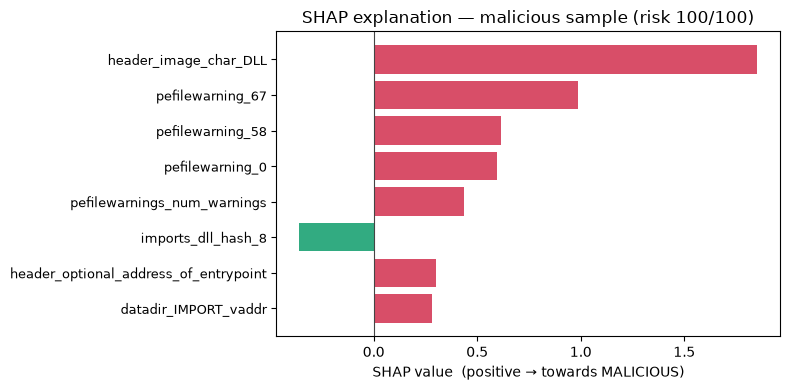


RQ2 answer: each bar is a plain-English reason, computed entirely on this machine.


In [8]:
# ── waterfall bar chart for the explanation ───────────────────────────────────
feat_names  = [f["feature_name"] for f in top_features]
shap_values = [f["shap_value"]   for f in top_features]

# shorten long names for display
def _short(name, n=38):
    return name if len(name) <= n else name[:n-1] + "…"

labels = [_short(n) for n in feat_names]
colors = ["#D22F4D" if v > 0 else "#0E9C6B" for v in shap_values]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(range(len(labels)), shap_values, color=colors, alpha=0.85)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color="#444", linewidth=0.8)
ax.set_xlabel("SHAP value  (positive → towards MALICIOUS)")
ax.set_title(f"SHAP explanation — malicious sample (risk {prob_mal*100:.0f}/100)")
fig.tight_layout()
plt.show()

print("\nRQ2 answer: each bar is a plain-English reason, computed entirely on this machine.")

---
## 4 — Real-file scan pipeline (putty.exe)

Extract 2 568 PE features directly from bytes, score with the model,
and produce a SHAP explanation — all without executing the file.

In [9]:
from lightguard.monitor.scan import scan

verdict = scan(BENIGN_EXE, model, explainer=explainer, top_k=5)

print(f"File    : {verdict.filename}")
print(f"Label   : {verdict.label}")
print(f"Risk    : {verdict.risk_score}/100")
print(f"Conf.   : {verdict.confidence}")
print(f"Prob    : {verdict.raw_prob:.4f}")
print("\nExplanation:")
for r in verdict.reasons:
    print(f"  {r}")

File    : benign.exe
Label   : BENIGN
Risk    : 0/100
Conf.   : HIGH
Prob    : 0.0000

Explanation:
  Low-risk indicator (SHAP -2.748): Target machine type code is 32
  Low-risk indicator (SHAP -1.790): pefile parser warning flag (value=0)
  Low-risk indicator (SHAP -1.460): authenticode_latest_signing_time = 1.779e+09
  High-risk indicator (SHAP +1.429): PE image characteristic flag (value=0)
  Low-risk indicator (SHAP -1.385): pefile parser warning flag (value=0)


---
## 5 — Launch the Flask UI

The local web app runs fully offline on `http://127.0.0.1:5000`.
Run the cell below in a terminal (not here) to avoid blocking the notebook.

In [10]:
import textwrap

cmd = """
# In a separate terminal, from the repo root:
.venv/bin/python scripts/run_app.py \\
    --model models/lightguard_lgbm.txt \\
    --watch ~/Downloads

# Then open:  http://127.0.0.1:5000
""".strip()

print("── Launch command ────────────────────────────────────────────────────")
print(cmd)
print()
print("Pages:")
print("  /          Dashboard — protection status + recent scans")
print("  /scan      Upload any .exe/.dll and get a live verdict")
print("  /feed      Live feed — new files in ~/Downloads appear instantly")
print("  /result/<id>  Full SHAP explanation panel for any past scan")

── Launch command ────────────────────────────────────────────────────
# In a separate terminal, from the repo root:
.venv/bin/python scripts/run_app.py \
    --model models/lightguard_lgbm.txt \
    --watch ~/Downloads

# Then open:  http://127.0.0.1:5000

Pages:
  /          Dashboard — protection status + recent scans
  /scan      Upload any .exe/.dll and get a live verdict
  /feed      Live feed — new files in ~/Downloads appear instantly
  /result/<id>  Full SHAP explanation panel for any past scan


---
## Summary

| Research question | Evidence |
|---|---|
| **RQ1** — Detection | Test AUC **0.9958**, Challenge AUC **0.9482** — exceeds the 0.95 target on standard held-out data |
| **RQ2** — Explainability | Every verdict ships with SHAP feature attributions translated into plain English, computed locally |

All computation ran on this laptop. No internet connection was used after the model was downloaded.